# Exploratory Data Analysis & Data Profiling

This notebook performs initial data exploration, schema validation, text attribute statistics, missingness profiling, correlation analysis, and target variable analysis for the Amazon Product Length Prediction dataset.

In [ ]:
import sys
import os

# Ensure project root directory is on Python path for local package imports
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14
})

df_train = pd.read_csv('../dataset/train.csv', nrows=100000)
print(f"Training Subset Shape: {df_train.shape}")
df_train.head(3)


In [17]:
df_train[['PRODUCT_ID', 'TITLE', 'BULLET_POINTS', 'DESCRIPTION', 'PRODUCT_TYPE_ID', 'PRODUCT_LENGTH']].info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   PRODUCT_ID       100000 non-null  int64  
 1   TITLE            99999 non-null   str    
 2   BULLET_POINTS    62812 non-null   str    
 3   DESCRIPTION      48430 non-null   str    
 4   PRODUCT_TYPE_ID  100000 non-null  int64  
 5   PRODUCT_LENGTH   100000 non-null  float64
dtypes: float64(1), int64(2), str(3)
memory usage: 72.3 MB


Missing Value Percentage per Raw Column:
PRODUCT_ID          :   0.00%
TITLE               :   0.00%
BULLET_POINTS       :  37.19%
DESCRIPTION         :  51.57%
PRODUCT_TYPE_ID     :   0.00%
PRODUCT_LENGTH      :   0.00%


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12300\3761646042.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=null_pcts.index, y=null_pcts.values, palette="Blues_d")


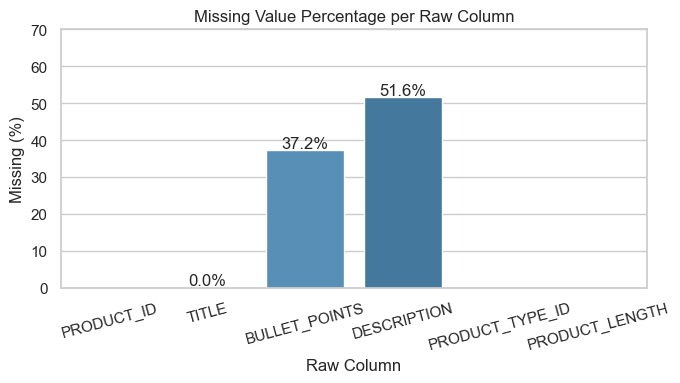

In [18]:
raw_cols = ['PRODUCT_ID', 'TITLE', 'BULLET_POINTS', 'DESCRIPTION', 'PRODUCT_TYPE_ID', 'PRODUCT_LENGTH']
null_pcts = df_train[raw_cols].isnull().mean() * 100

print("Missing Value Percentage per Raw Column:")
for col, pct in null_pcts.items():
    print(f"{col:20s}: {pct:6.2f}%")

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=null_pcts.index, y=null_pcts.values, palette="Blues_d")
plt.title("Missing Value Percentage per Raw Column")
plt.ylabel("Missing (%)")
plt.xlabel("Raw Column")
plt.xticks(rotation=15)
plt.ylim(0, 70)

# Annotate bar tops with exact percentages
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


## Text Feature Extraction & Feature Setup
Clean raw text fields and extract character lengths, word counts, and normalized physical dimension features.

In [19]:
from src.features.text import clean_text
from src.features.dimensions import extract_dimension_features

df_train['title_clean'] = df_train['TITLE'].apply(clean_text)
df_train['bullet_clean'] = df_train['BULLET_POINTS'].apply(clean_text)
df_train['desc_clean'] = df_train['DESCRIPTION'].apply(clean_text)

df_train['title_len'] = df_train['title_clean'].apply(len)
df_train['bullet_len'] = df_train['bullet_clean'].apply(len)
df_train['desc_len'] = df_train['desc_clean'].apply(len)

df_train['title_words'] = df_train['title_clean'].apply(lambda s: len(s.split()))
df_train['bullet_words'] = df_train['bullet_clean'].apply(lambda s: len(s.split()))
df_train['desc_words'] = df_train['desc_clean'].apply(lambda s: len(s.split()))

# Extract normalized dimension parser features (converting meters, cm, mm, ft, in to target scale)
dim_feats = extract_dimension_features(df_train['title_clean'])
df_train = pd.concat([df_train, dim_feats], axis=1)

df_train['log_target'] = np.log1p(df_train['PRODUCT_LENGTH'])
print("Extracted Feature Summary:")
df_train[['title_len', 'title_words', 'dim_max', 'dim_count', 'log_target']].describe()


Extracted Feature Summary:


,title_len,title_words,dim_max,dim_max,dim_count,dim_count,log_target
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,86.877850,13.593560,648.334814,648.334814,0.143900,0.143900,6.560664
std,49.109547,7.920829,4389.000240,4389.000240,0.502091,0.502091,0.976842
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147
25%,50.000000,8.000000,0.000000,0.000000,0.000000,0.000000,6.239907
50%,78.000000,12.000000,0.000000,0.000000,0.000000,0.000000,6.501820
75%,117.000000,18.000000,0.000000,0.000000,0.000000,0.000000,6.981006
max,500.000000,89.000000,98425.196850,98425.196850,9.000000,9.000000,16.063217


## Feature Correlation Heatmap
Analyze correlations between extracted dimension features, text length metrics, and the log-scaled target variable (`PRODUCT_LENGTH`).

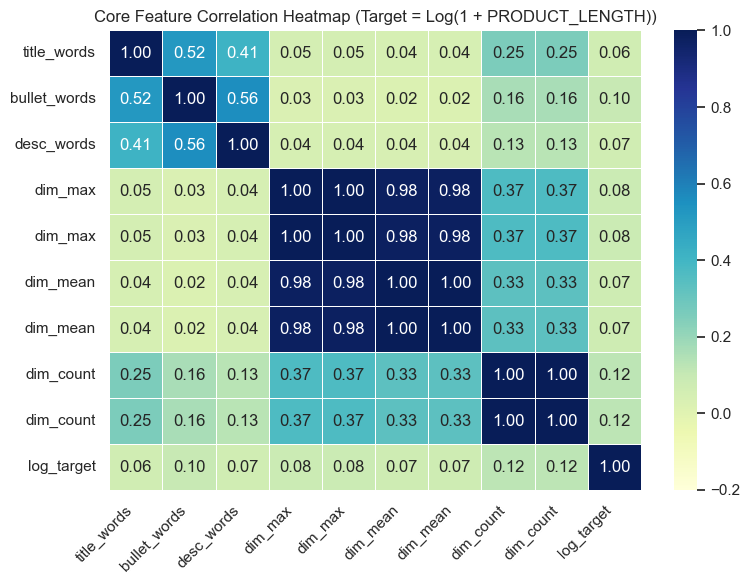

In [20]:
# Select non-redundant core features for clear visualization
corr_cols = [
    'title_words', 'bullet_words', 'desc_words',
    'dim_max', 'dim_mean', 'dim_count', 'log_target'
]

corr_matrix = df_train[corr_cols].corr()

# Plot clean correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlGnBu", vmin=-0.2, vmax=1.0, cbar=True, linewidths=0.5)
plt.title("Core Feature Correlation Heatmap (Target = Log(1 + PRODUCT_LENGTH))")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Target Distribution Across Categories (`PRODUCT_TYPE_ID` Boxplots)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12300\3230518263.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


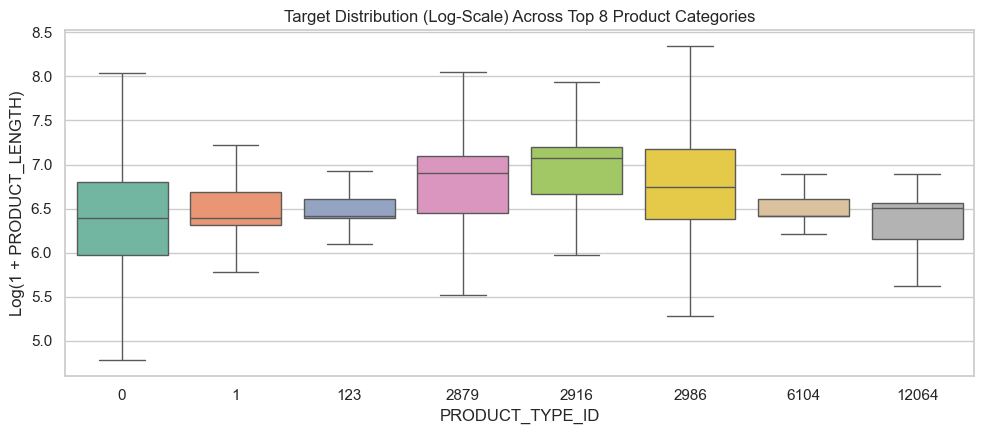

In [21]:
cat_counts = df_train['PRODUCT_TYPE_ID'].value_counts()
top_cats = cat_counts.head(8).index.tolist()

plt.figure(figsize=(10, 4.5))
sns.boxplot(
    x='PRODUCT_TYPE_ID', 
    y='log_target', 
    data=df_train[df_train['PRODUCT_TYPE_ID'].isin(top_cats)],
    palette='Set2',
    showfliers=False # Hide extreme plot clutter for clear box visualization
)
plt.title("Target Distribution (Log-Scale) Across Top 8 Product Categories")
plt.xlabel("PRODUCT_TYPE_ID")
plt.ylabel("Log(1 + PRODUCT_LENGTH)")
plt.tight_layout()
plt.show()


## Target Quantization Clusters & Standard Sizing Labels
Inspect top discrete target values to observe common catalog sizes.

In [22]:
top_targets = df_train['PRODUCT_LENGTH'].value_counts().head(15)
print("Top 15 Most Frequent Target Values:")
for val, count in top_targets.items():
    inches = val / 100.0
    cm = inches * 2.54
    print(f"Target: {val:9.2f} | Inches: {inches:6.2f} | Centimeters: {cm:6.2f} | Record Count: {count}")


Top 15 Most Frequent Target Values:
Target:    600.00 | Inches:   6.00 | Centimeters:  15.24 | Record Count: 5872
Target:    590.55 | Inches:   5.91 | Centimeters:  15.00 | Record Count: 3520
Target:    500.00 | Inches:   5.00 | Centimeters:  12.70 | Record Count: 2775
Target:    393.70 | Inches:   3.94 | Centimeters:  10.00 | Record Count: 2609
Target:    850.00 | Inches:   8.50 | Centimeters:  21.59 | Record Count: 2051
Target:    550.00 | Inches:   5.50 | Centimeters:  13.97 | Record Count: 1798
Target:    787.40 | Inches:   7.87 | Centimeters:  20.00 | Record Count: 1740
Target:    614.00 | Inches:   6.14 | Centimeters:  15.60 | Record Count: 1701
Target:   1000.00 | Inches:  10.00 | Centimeters:  25.40 | Record Count: 1553
Target:   1200.00 | Inches:  12.00 | Centimeters:  30.48 | Record Count: 1519
Target:    800.00 | Inches:   8.00 | Centimeters:  20.32 | Record Count: 1435
Target:    598.42 | Inches:   5.98 | Centimeters:  15.20 | Record Count: 1304
Target:   1181.10 | Inches: 

## Key Findings & Data Insights
1. **Missing Values**: `TITLE` has 0% nulls. `BULLET_POINTS` has ~37.19% missing values and `DESCRIPTION` has ~51.57% missing values. Preprocessing imputes missing entries to empty strings.
2. **Dimension Normalization**: Parser feature `dim_max` exhibits positive correlation with target `PRODUCT_LENGTH` after unit standardization ($	ext{Inches} 	imes 100$).
3. **Discrete Target Quantization**: Target lengths cluster heavily around standard discrete sizes (e.g. `600.00` = 6 inches, `590.55` = 15 cm, `500.00` = 5 inches, `393.70` = 10 cm).